In [2]:
import sys,os
sys.path.insert(0, os.path.abspath("/cs/usr/roeizucker/new_storage/jupyter_notebooks/Tom_Hope_Project/refactored_code/src"))
import pandas as pd
import numpy as np
from datasets import Dataset, DatasetDict, load_from_disk
import yaml
import os, sys
# sys.path.insert(0, os.path.abspath("/cs/usr/roeizucker/new_storage/jupyter_notebooks/Tom_Hope_Project/refactored_code"))
from datetime import datetime

from constants import (RAW_INPUT_NAME, 
                           CPG_SEPERATING_SITES_TASK_NAME,
                           INTERMEDIATE_INPUT_NAME, 
                           PREPROCESSED_INPUT_NAME, 
                           CPG_TRAINING_TASK_TYPE, 
                           CPG_RETRAINING_TASK_TYPE,
                           CPG_EVALUATION_TASK_TYPE,
                           SAVED_EPOCH_PREFIX,
                           EVALUATE_MULTIPLE_CHCEKPOINTS_SUBTASK_TYPE,
                           BINS_GROUPING_METHOD,
                           DEFAULT_FULL_POSITION_COLUMN_NAME,
                           REGRESSION_ANALYSIS_SYMBOL,
                           BLANK_LABEL_VALUE,
                           STD_VARIABILITY_TYPE,
                           QUANTILE_SEPERATION_TYPE
                           )
from config_manager import (run_presets,
                                CREATE_PROJECT_TASK_NUM,
                                DATA_EXTRQACTION_TASK_NUM,
                                MODEL_TRAINING_TASK_NUM,
                                MODEL_EVALUATION_TASK_NUM,
                                create_base_dictionary,
                                create_data_extraction_config_dict,
                                DEFAULT_CONFIG_PATH,
                                create_project_config,
                                DEFAULT_CREATE_BASIC_EXTRACTION_FILES,
                                ask_for_tokenizer_name,
                                get_files_names_from_file_list,
                                CONFIG_DIR_PATH,
                                HUGGINGFACE_DATASET_BASE_DIR,
                                TRAINED_HUGGINGFACE_MODELS_LOCATION,
                                CREATE_PROJECT_HP_OPTIMIZATION_TASK_NUM,
                                # print_commands_for_roject_config
                                )
import matplotlib.pyplot as plt

In [4]:
# methylation rate in general - do graph
# methylation variability in general - do graph
# methylation variability depandent on rate
# 

df = pd.read_csv("/sci/archive/michall/roeizucker/huggingface_datasets_dir/4H_per_varaint_variability_HP_optimization_multi_project_config_datasets.csv")

In [5]:
low_var = (len(df))
high_var = len(df[df["std"] > 0.09])
high_var / low_var

0.1653500721941963

In [18]:
ds = load_from_disk("/sci/archive/michall/roeizucker/huggingface_datasets_dir/R3_pretrain_HP_optimization_multi_project_config_datasets_train")

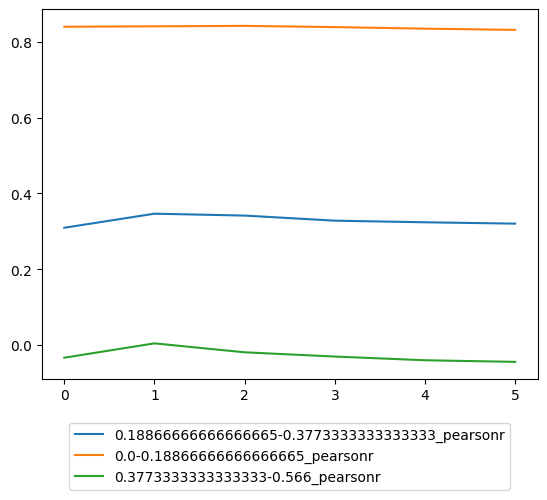

In [30]:
def display_results(project_dto,lr,batch_size):
    base_model_location = project_dto["base_model_location"]
    base_suffix = project_dto["project_suffix"]
    project_suffix = f"{base_suffix}_lr_{lr}_bs_{batch_size}"
    pretrain_name_suffix = "_pretrain" + project_suffix


    pretrain_name_suffix = "_pretrain" + project_suffix
    names = project_dto["names"]
    retrain_name_suffix = "_retrain" + project_suffix
    eval_created_configs_path_name_suffix="_eval" + project_suffix
    retrain_name_suffix = "_retrain" + project_suffix
    eval_name_suffix = eval_created_configs_path_name_suffix
    return print_eval(names,pretrain_name_suffix,eval_created_configs_path_name_suffix,
               base_model_location,retrain_name_suffix,eval_name_suffix)

def print_eval(names, pretrain_name_suffix, created_configs_path_name_suffix,
               base_model_location, retrain_name_suffix, eval_name_suffix):
    dfs = []
    for index in range(len(names)):
        curr_base_name = names[index]
        dfs.append([curr_base_name,[]])
        # eval_dataset_path = os.path.join(dataset_base_dir,names[index]  + created_datasets_retrain_base_name_suffix + "_test")
        base_models_path =  os.path.join(base_model_location,curr_base_name + pretrain_name_suffix)
        existing_model_names = []
        if not os.path.exists(base_models_path):
            continue
        for file in os.listdir(base_models_path):
            if file.startswith(SAVED_EPOCH_PREFIX):
                existing_model_names.append(file)
        for name in existing_model_names:
            curr_retrain_name_suffix = "_" + name + retrain_name_suffix
            curr_eval_name_suffix = "_" + name + eval_name_suffix
            curr_created_configs_path_name_suffix = "_" + name + created_configs_path_name_suffix
            # pretrained_model_path = os.path.join(base_models_path,name)
            curr_models_base_path = os.path.join(base_model_location,curr_base_name + curr_retrain_name_suffix)

            
            analysis_name = curr_base_name + curr_eval_name_suffix
            res_path = os.path.join("/cs/usr/roeizucker/new_storage/jupyter_notebooks/Tom_Hope_Project/results",analysis_name)
            result_file_name = os.path.join(res_path,"resilt.csv")
            if os.path.exists(result_file_name):
                df = pd.read_csv(result_file_name)
                dfs[-1][1].append([name,df])
    return dfs



            
path = "/cs/usr/roeizucker/new_storage/jupyter_notebooks/Tom_Hope_Project/refactored_code/configs/project_configs/_HP_optimization_multi_project_config.yaml"

person_of_interest = 0
DATA_POSITION = 1

# column_of_interest = "0.18866666666666665-0.3773333333333333_pearsonr"
column_of_interest = "0.3773333333333333-0.566_pearsonr"
# learning_rates = [1e-05,1e-06,1e-07]
# batch_sizes = [2,4]
learning_rates = [1e-06]
batch_sizes = [2]
for lr in learning_rates:
    # print("lr",lr)
    for batch_size in batch_sizes:
        curr_plot_df = None
        for epoch_name, df in sorted(display_results(yaml.safe_load(open(path))["params"],lr,batch_size)[person_of_interest][DATA_POSITION]):
            epoch_name_clean = epoch_name.split("-step")[0]
            df["paths"] = df["paths"].str.split("/").str[-1].str.split("-").str[0:2].str.join("-")
            df.loc[0,"paths"] = "epoch-0" 
            
            curr_df = df.sort_values(by="paths").reset_index()[["paths",column_of_interest]]
            if curr_plot_df is None:
                
                curr_plot_df = curr_df.rename(columns={column_of_interest: epoch_name_clean + "_" + column_of_interest})
            else:
                curr_plot_df[ epoch_name_clean + "_" + column_of_interest] = curr_df[column_of_interest]
        # print(curr_plot_df)
        # curr_plot_df.plot().legend(loc='upper center', bbox_to_anchor=(0.5, -0.1))
        # # print(curr_plot_df)
        # plt.title(f"{lr} - {batch_size}")
        # plt.show()

specific_lr = 1e-06
specific_bs = 2

df = display_results(yaml.safe_load(open(path))["params"],specific_lr,specific_bs)[person_of_interest][DATA_POSITION][2][1]
df["paths"] = df["paths"].str.split("/").str[-1].str.split("-").str[0:2].str.join("-")
df.loc[0,"paths"] = "epoch-0" 
            
curr_df = df.sort_values(by="paths").reset_index()
curr_df[[x for x in curr_df.columns if "pearsonr" in x]].plot().legend(loc='upper center', bbox_to_anchor=(0.5, -0.1))
plt.show()
# print(display_results(yaml.safe_load(open(path))["params"],specific_lr,specific_bs)[person_of_interest][DATA_POSITION][2][0])
# print(df[[x for x in df.columns if "pearsonr" in x]])

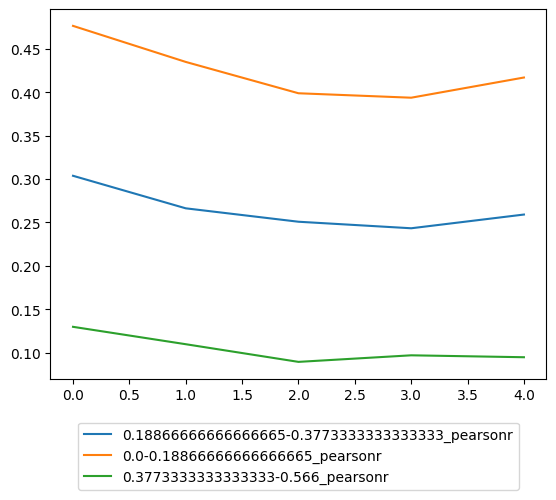

In [31]:
df = pd.read_csv("/cs/usr/roeizucker/new_storage/jupyter_notebooks/Tom_Hope_Project/results/R3_epoch-0-step-97898_eval_HP_optimization_multi_project_config_lr_1e-06_bs_2_no_pretrain_medium_only/resilt.csv")
df["paths"] = df["paths"].str.split("/").str[-1].str.split("-").str[0:2].str.join("-")
df.loc[0,"paths"] = "epoch-0" 
curr_df = df.sort_values(by="paths").reset_index()
curr_df[[x for x in curr_df.columns if "pearsonr" in x]].plot().legend(loc='upper center', bbox_to_anchor=(0.5, -0.1))
plt.show()

In [1]:
from datasets import Dataset, DatasetDict, load_from_disk

/cs/usr/roeizucker/new_storage/miniconda3/envs/nir_evo_env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [18]:
import pandas as pd
import numpy as np

In [6]:
ds = load_from_disk("/sci/archive/michall/roeizucker/huggingface_datasets_dir/R3_retrain_after_HPO_lr_06_bs_2_chr1-10_train")

In [7]:
ds

Dataset({
    features: ['seq', 'labels', 'start', 'end', 'window_id', 'input_ids', 'attention_mask'],
    num_rows: 258746
})

In [13]:
all_counts = []
for i in range(len(ds)):
    print(i,len(ds),end="\r")
    curr_reg = ds[i]
    count = 0 
    for lab in ((curr_reg["labels"])):
        if lab != -100:
            count+=1
    all_counts.append(count)

In [20]:
print(min(all_counts))
print(max(all_counts))
print(np.mean(all_counts) / 901)

1
274
0.041079937432175875


In [21]:
all_counts_zero = []
for i in range(len(ds)):
    print(i,len(ds),end="\r")
    curr_reg = ds[i]
    count = 0 
    for lab in ((curr_reg["labels"])):
        if lab != -100 and lab < 0.05:
            count+=1
    all_counts_zero.append(count)

In [ ]:
print(min(all_counts_zero))
print(max(all_counts_zero))
print(np.mean(all_counts_zero) / 901 )

0
71
0.0006878705849634449


In [27]:
0.0006878705849634449 / 0.041079937432175875 

0.01674468433889751

In [3]:
import pandas as pd
var_df = pd.read_csv("/sci/archive/michall/roeizucker/huggingface_datasets_dir/R3_per_varaint_variability_after_HPO_lr_06_bs_2_chr1-10.csv")

In [ ]:
val = "0.0-0.05347_pearsonr	0.05347-0.10694_pearsonr	0.10694-0.16041_pearsonr	0.16041-0.21388_pearsonr	0.21388-0.26735_pearsonr	0.26735-0.32082_pearsonr	0.32082-0.37428999999999996_pearsonr	0.37428999999999996-0.42776_pearsonr	0.42776-0.48123_pearsonr	0.48123-0.5347_pearsonr"
vals = val.replace("_pearsonr","").split("\t")
for val in vals:
    a = val.split("-")
    low = float(a[0])
    high = float(a[1])
    print(a)
    print(len(var_df[(var_df["std" ]>= low) & (var_df["std" ]< high)]))


8057389
4364041
1415851
403788
194960
73998
33701
30227
4944
935


In [16]:
var_df

,Unnamed: 0,full_position,window_id,std,high_diff
0,0,chr1:10468-10470,chr1:5400-10800,0.10455,True
1,1,chr1:10470-10472,chr1:5400-10800,0.07947,True
2,2,chr1:10483-10485,chr1:5400-10800,0.05603,True
3,3,chr1:10488-10490,chr1:5400-10800,0.05100,True
4,4,chr1:10492-10494,chr1:5400-10800,0.14270,True
...,...,...,...,...,...
14579830,14579830,chr10:133787110-133787112,chr10:133785000-133790400,0.05493,True
14579831,14579831,chr10:133787117-133787119,chr10:133785000-133790400,0.10770,True
14579832,14579832,chr10:133787122-133787124,chr10:133785000-133790400,0.08170,True
14579833,14579833,chr10:133787243-133787245,chr10:133785000-133790400,0.04578,True


In [6]:
var_df["std"].quantile(0.9)

0.1251

In [31]:
var_df["std"].mean()

0.06502831111604368

In [ ]:
0.0-0.18866666666666665
0.18866666666666665-0.3773333333333333
0.3773333333333333-0.566

In [11]:
var_df[(var_df["std"] > 0.189) & (var_df["std"] < 0.566)]

,Unnamed: 0,full_position,window_id,std,high_diff
0,0,chr5:11822-11824,chr5:10800-16200,0.3450,True
1,1,chr5:11849-11851,chr5:10800-16200,0.2385,True
19,19,chr5:12355-12357,chr5:10800-16200,0.2097,True
23,23,chr5:12401-12403,chr5:10800-16200,0.2196,True
36,36,chr5:12494-12496,chr5:10800-16200,0.3160,True
...,...,...,...,...,...
1403337,1403337,chr5:181457971-181457973,chr5:181456200-181461600,0.2166,True
1403347,1403347,chr5:181458326-181458328,chr5:181456200-181461600,0.2512,True
1403348,1403348,chr5:181458358-181458360,chr5:181456200-181461600,0.2546,True
1403350,1403350,chr5:181463197-181463199,chr5:181461600-181467000,0.2008,True


In [6]:
var_df[var_df["std"] > 0.3773333333333333]["window_id"].value_counts().head(20).sort_index()

window_id
chr5:10605600-10611000      21
chr5:1096200-1101600        56
chr5:1107000-1112400        53
chr5:134919000-134924400    24
chr5:134924400-134929800    36
chr5:138272400-138277800    22
chr5:140427000-140432400    17
chr5:148824000-148829400    16
chr5:154688400-154693800    15
chr5:159969600-159975000    17
chr5:172681200-172686600    16
chr5:172767600-172773000    17
chr5:177476400-177481800    16
chr5:42546600-42552000      22
chr5:68742000-68747400      17
chr5:80649000-80654400      21
chr5:88187400-88192800      15
chr5:955800-961200          31
chr5:95850000-95855400      41
chr5:95855400-95860800      16
Name: count, dtype: int64

In [ ]:
var_df[vdar_df["window_id"] == "chr5:95860800-95866200"]["std"].max()

0.335